### 1) Project Overview

### Delivery Time Prediction using Machine Learning

### 2) Business Problem

### 3) Objectives

### 4) Dataset Information

### 5) Technologies Used

### 6) Project Workflow

#### 1) Import Libraries

In [1]:
# Basic
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model Selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#### 2) Data Collection

In [2]:
del_time = pd.read_csv('C:/Users/Admin/Documents/GitHub/delivery-time-prediction-linear-regression/Dataset/Food Delivery Times.csv')
del_time

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


#### 3) Data Understanding

In [3]:
del_time.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [4]:
del_time.tail()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55
999,103,6.63,Foggy,Low,Night,Scooter,24,3.0,58


In [5]:
del_time.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

#### 4) Explortary Data Analysis (EDA)

#### 1) Dataset Shape

In [6]:
del_time.shape

(1000, 9)

#### 2) Data Type

In [7]:
del_time.dtypes

Order_ID                    int64
Distance_km               float64
Weather                    object
Traffic_Level              object
Time_of_Day                object
Vehicle_Type               object
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object

#### 3) Missing Values

In [8]:
del_time.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

##### Observation

#### 4) Duplicate Values

In [9]:
del_time.duplicated().sum()

np.int64(0)

#### 5) Statistical Summary

In [10]:
del_time.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


#### 6) Correlation Analysis

In [11]:
del_time.corr(numeric_only=True)

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
Order_ID,1.000000,-0.024483,-0.035100,0.013152,-0.036650
Distance_km,-0.024483,1.000000,-0.009037,-0.007842,0.780998
Preparation_Time_min,-0.035100,-0.009037,1.000000,-0.030830,0.307350
Courier_Experience_yrs,0.013152,-0.007842,-0.030830,1.000000,-0.090433
Delivery_Time_min,-0.036650,0.780998,0.307350,-0.090433,1.000000


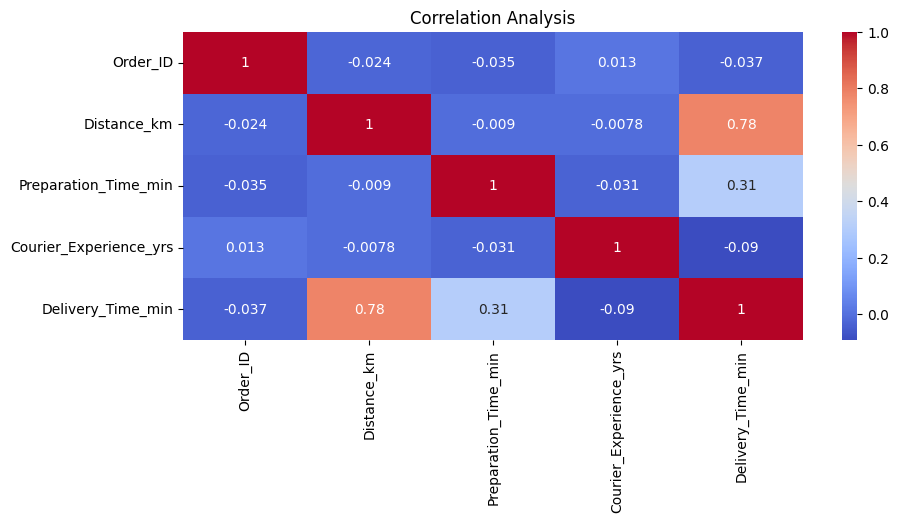

In [12]:
# Visulation 

plt.figure(figsize=(10,4))

sns.heatmap(del_time.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title('Correlation Analysis')

plt.show()

#### 7) Class Distribution

In [13]:
del_time.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [14]:
del_time['Order_ID'].unique().sum()

np.int64(500500)

In [15]:
del_time['Distance_km'].unique().sum()

np.float64(7896.21)

In [16]:
del_time['Weather'].value_counts()

Weather
Clear    470
Rainy    204
Foggy    103
Snowy     97
Windy     96
Name: count, dtype: int64

In [17]:
del_time['Traffic_Level'].value_counts()

Traffic_Level
Medium    390
Low       383
High      197
Name: count, dtype: int64

In [18]:
del_time['Time_of_Day'].value_counts()

Time_of_Day
Morning      308
Evening      293
Afternoon    284
Night         85
Name: count, dtype: int64

In [19]:
del_time['Vehicle_Type'].value_counts()

Vehicle_Type
Bike       503
Scooter    302
Car        195
Name: count, dtype: int64

In [20]:
del_time['Preparation_Time_min'].unique().sum()

np.int64(425)

In [21]:
del_time['Courier_Experience_yrs'].value_counts()

Courier_Experience_yrs
6.0    109
9.0    108
1.0    107
8.0    101
2.0     99
4.0     94
0.0     91
7.0     91
5.0     90
3.0     80
Name: count, dtype: int64

#### 8) Outliers Detection

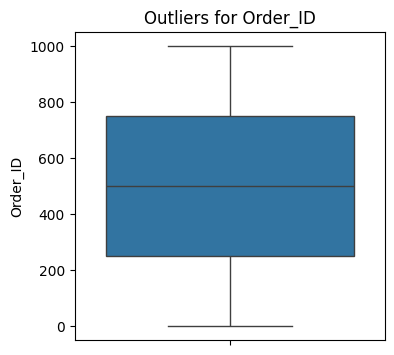

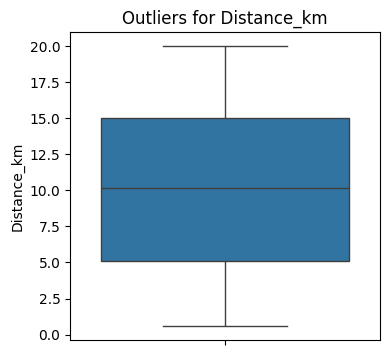

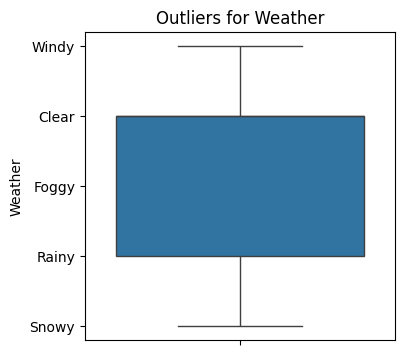

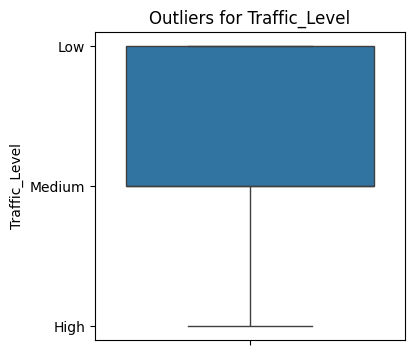

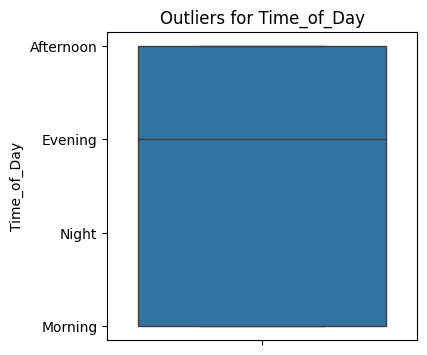

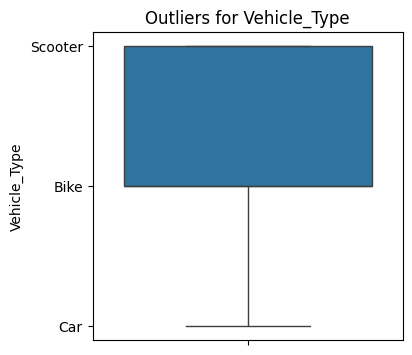

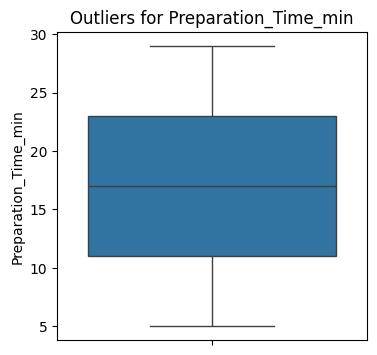

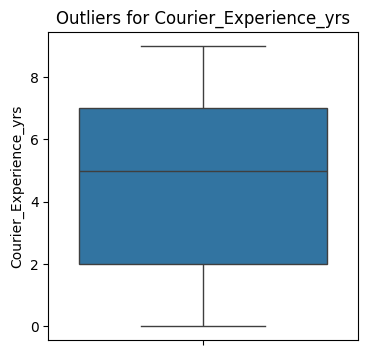

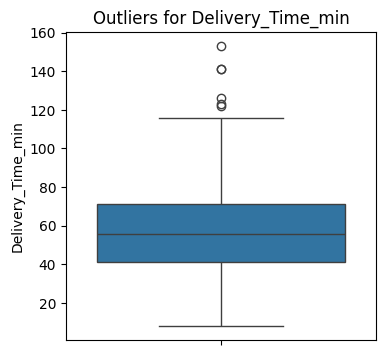

In [22]:
columns = del_time.columns

for out_col in columns:
    plt.figure(figsize=(4,4))
    sns.boxplot(data=del_time[out_col])
    plt.title(f'Outliers for {out_col}')
    plt.show()


##### Observation

#### 9) Feature Distribution

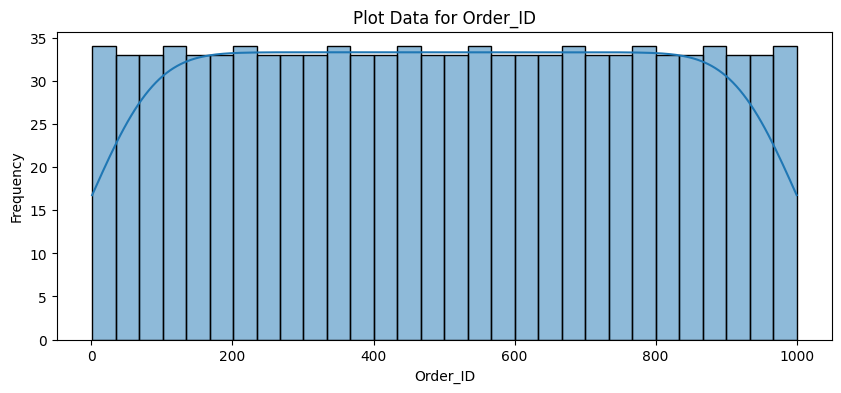

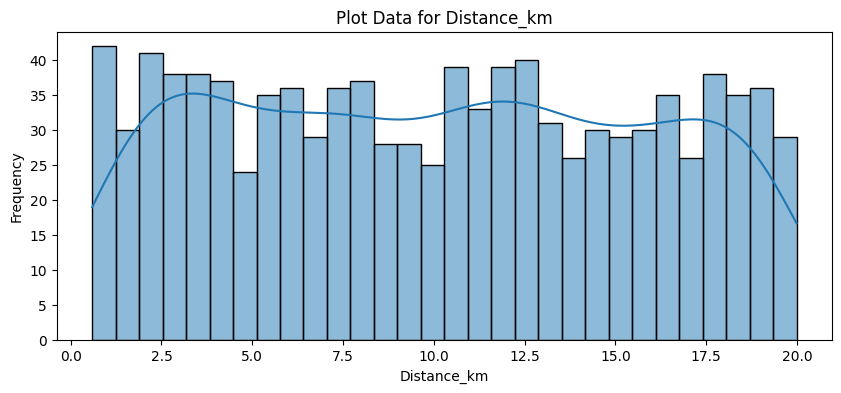

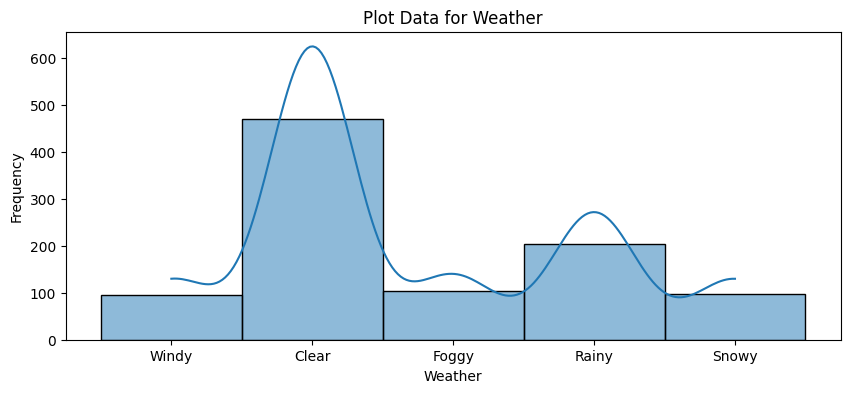

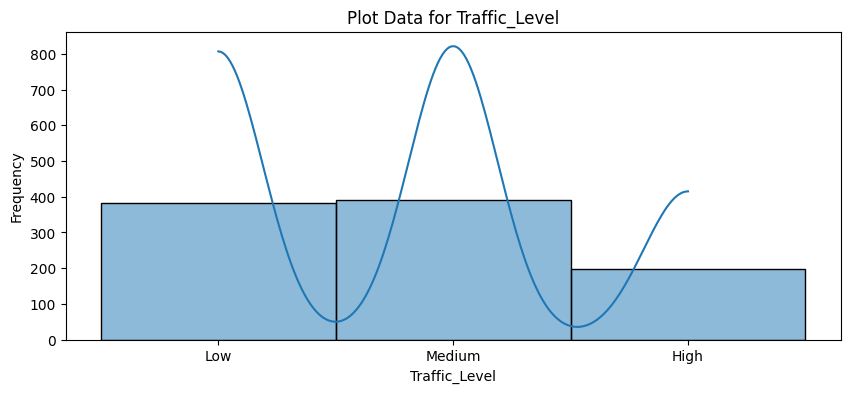

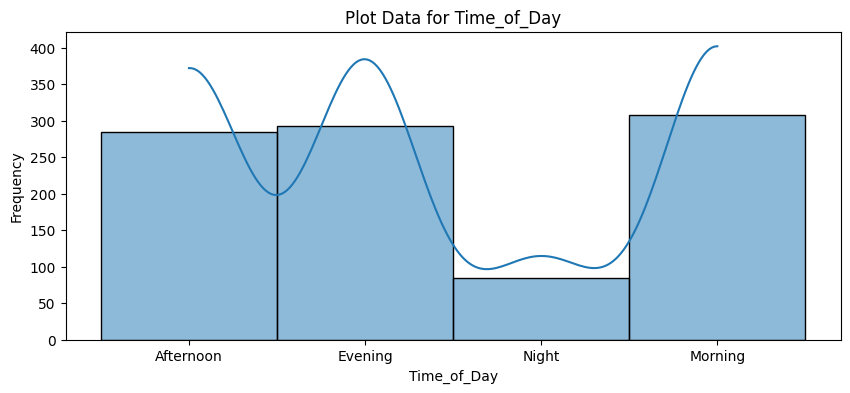

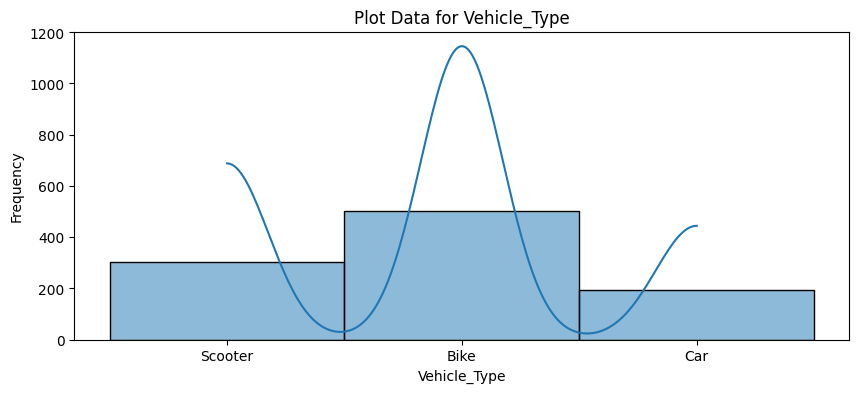

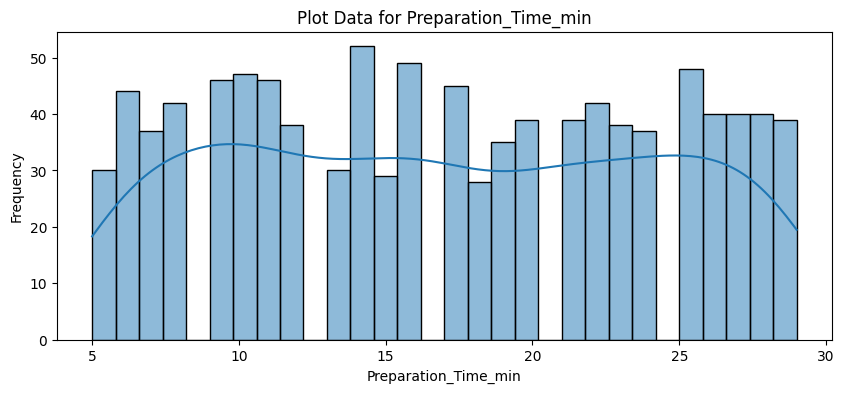

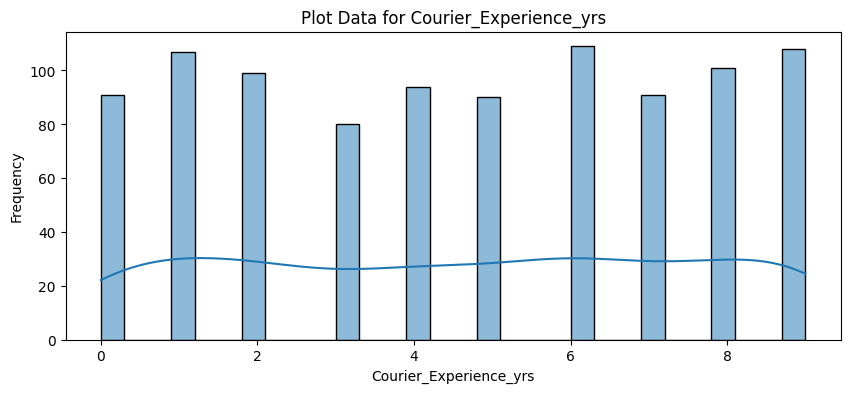

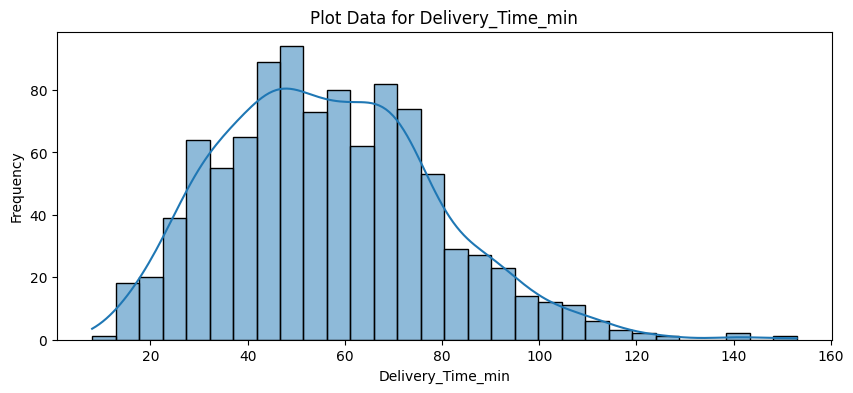

In [23]:
columns = del_time.columns

for a in columns:
    plt.figure(figsize=(10,4))

    sns.histplot(del_time[a], bins=30, kde=True)

    plt.title(f'Plot Data for {a}')
    plt.xlabel(a)
    plt.ylabel('Frequency')
    plt.show()

##### Observation

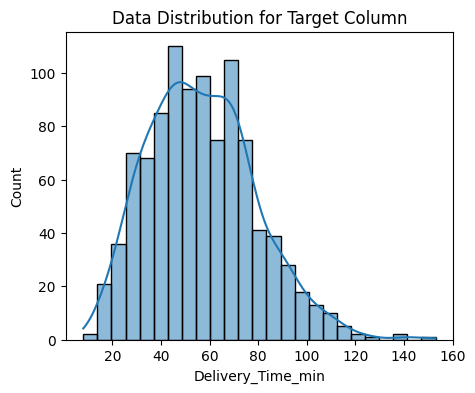

In [24]:
target_col = del_time['Delivery_Time_min']

plt.figure(figsize=(5,4))

sns.histplot(target_col, kde=True)

plt.title('Data Distribution for Target Column')

plt.show()

#### Bi-Variant 

In [25]:
del_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


<Axes: xlabel='Distance_km', ylabel='Delivery_Time_min'>

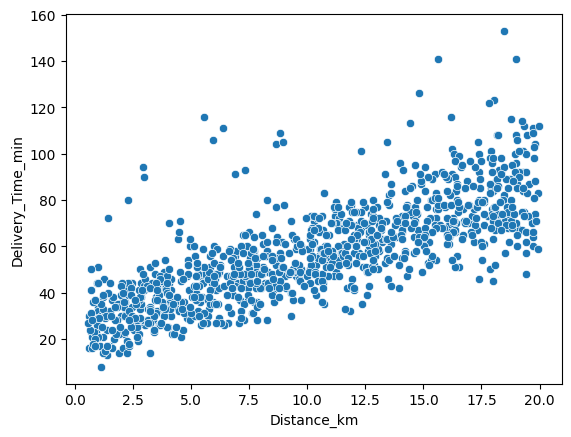

In [26]:
# Distance km vs Delivery Time min

sns.scatterplot(x='Distance_km',
                y='Delivery_Time_min',
                data=del_time
               )

##### Observation

<Axes: xlabel='Weather', ylabel='Delivery_Time_min'>

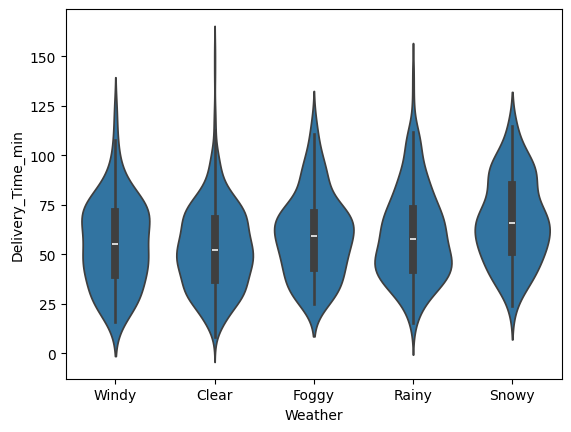

In [27]:
# Weather vs Delivery time min

sns.violinplot(x='Weather',
            y='Delivery_Time_min',
            data=del_time)

##### Observation

<Axes: xlabel='Traffic_Level', ylabel='Delivery_Time_min'>

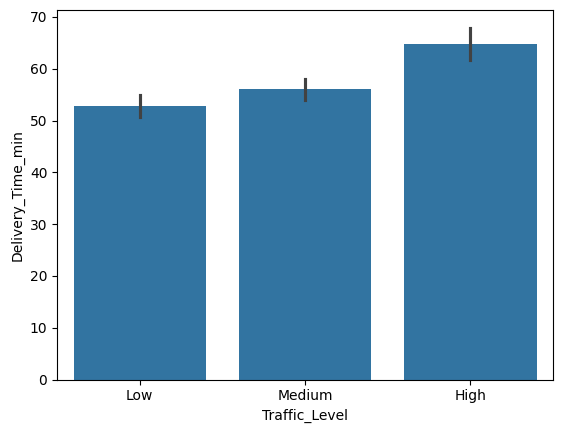

In [28]:
# Traffic Levels vs Delivery Time Minutes (C vs N)

sns.barplot(x='Traffic_Level',
            y='Delivery_Time_min',
            data=del_time
           )

##### Observation

<Axes: xlabel='Preparation_Time_min', ylabel='Delivery_Time_min'>

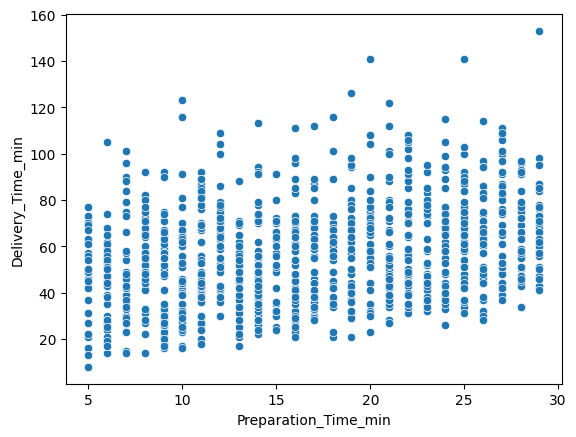

In [29]:
# Preparation Time min vs Delivery Time min (N vs N)

sns.scatterplot(x='Preparation_Time_min',
             y='Delivery_Time_min',
             data=del_time
            )

#### Multi-Variant Analysis

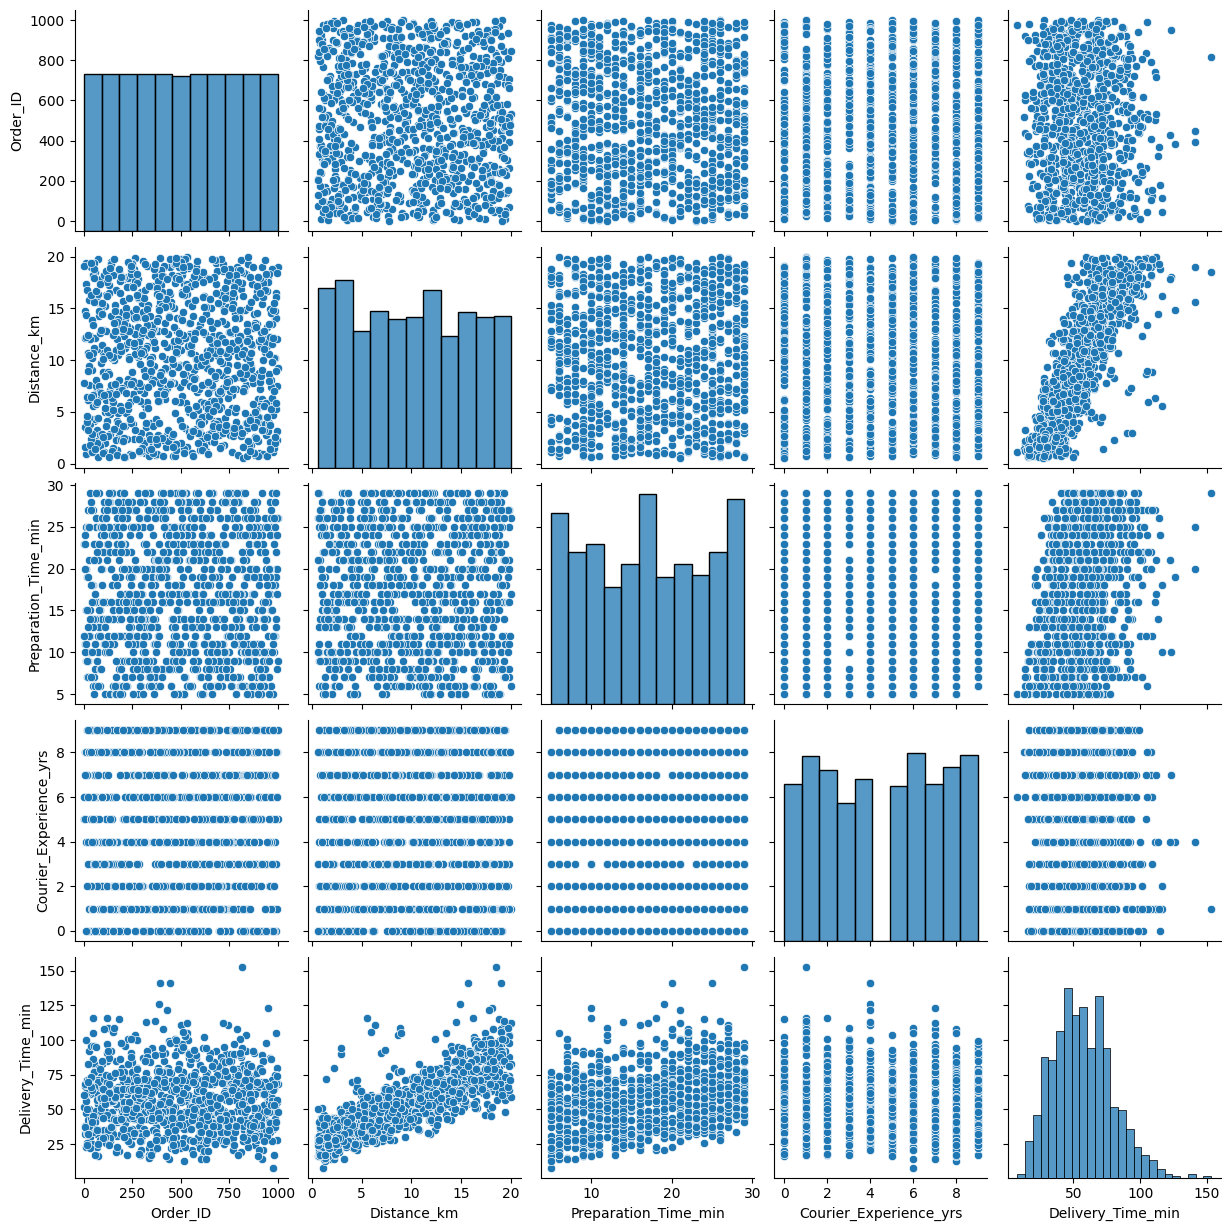

In [30]:
sns.pairplot(data=del_time)
plt.show()

#### 10) Data Cleaning

##### 1) Handling Duplicates (Not needed)

##### 2) Handling Missing Values

In [31]:
del_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [32]:
# For Categorical Data
cat_cols = ['Weather', 'Traffic_Level', 'Time_of_Day']

for cols in cat_cols:
    del_time[cols] = del_time[cols].fillna(del_time[cols].mode()[0])    

In [33]:
# For Numerical Data
del_time['Courier_Experience_yrs'] = del_time['Courier_Experience_yrs'].fillna(del_time['Courier_Experience_yrs'].median())

In [34]:
del_time.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

##### 3) Handling Outliers

In [35]:
feature_cols = 'Delivery_Time_min'
Q1 = del_time[feature_cols].quantile(0.25)
Q3 = del_time[feature_cols].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

del_time[feature_cols] = del_time[feature_cols].clip(lower=lower, upper=upper)

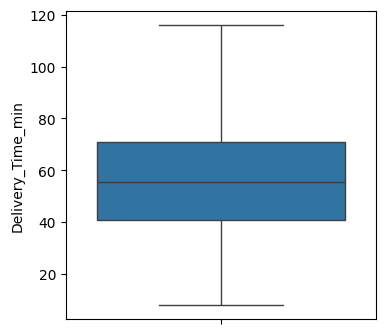

In [36]:
plt.figure(figsize=(4,4))

sns.boxplot(del_time['Delivery_Time_min'])
plt.show()

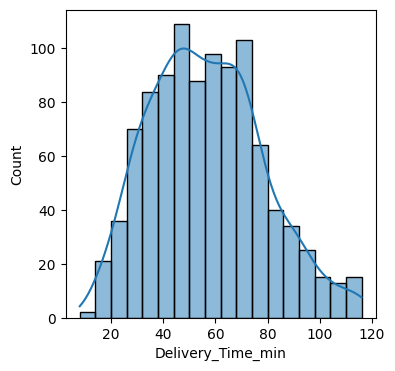

In [37]:
plt.figure(figsize=(4,4))

sns.histplot(del_time['Delivery_Time_min'], kde=True)
plt.show()

##### Observation

#### 11) Feature Engineering

In [38]:
del_time.head(2)

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84


##### 1) Apply Encoding Technique for Categorical Column (One hot encoding and Label Encoding)

In [39]:
# Weather and Vehicle Type (One-Hot Encoding) OHE

del_time = pd.get_dummies(
    del_time,
    columns=['Weather', 'Vehicle_Type'],
    drop_first=True
)

del_time.head() 

,Order_ID,Distance_km,Traffic_Level,Time_of_Day,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,7.93,Low,Afternoon,12,1.0,43,False,False,False,True,False,True
1,738,16.42,Medium,Evening,20,2.0,84,False,False,False,False,False,False
2,741,9.52,Low,Night,28,1.0,59,True,False,False,False,False,True
3,661,7.44,Medium,Afternoon,5,1.0,37,False,True,False,False,False,True
4,412,19.03,Low,Morning,16,5.0,68,False,False,False,False,False,False


##### Observation 

In [40]:
# Traffic Level and Time of Day (Label Encoding)
le = LabelEncoder()

del_time['Traffic_Level'] = le.fit_transform(del_time['Traffic_Level'])
del_time['Time_of_Day'] = le.fit_transform(del_time['Time_of_Day'])

del_time.head()

,Order_ID,Distance_km,Traffic_Level,Time_of_Day,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,7.93,1,0,12,1.0,43,False,False,False,True,False,True
1,738,16.42,2,1,20,2.0,84,False,False,False,False,False,False
2,741,9.52,1,3,28,1.0,59,True,False,False,False,False,True
3,661,7.44,2,0,5,1.0,37,False,True,False,False,False,True
4,412,19.03,1,2,16,5.0,68,False,False,False,False,False,False


##### Observation

##### 2) Remove Order ID column

In [41]:
del_time.drop('Order_ID', axis=1, inplace=True)

In [42]:
del_time.head()

,Distance_km,Traffic_Level,Time_of_Day,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Vehicle_Type_Car,Vehicle_Type_Scooter
0,7.93,1,0,12,1.0,43,False,False,False,True,False,True
1,16.42,2,1,20,2.0,84,False,False,False,False,False,False
2,9.52,1,3,28,1.0,59,True,False,False,False,False,True
3,7.44,2,0,5,1.0,37,False,True,False,False,False,True
4,19.03,1,2,16,5.0,68,False,False,False,False,False,False


#### 12) Data Preprocessing

##### 1) Feature Selection

In [43]:
X = del_time.drop('Delivery_Time_min', axis=1)
y = del_time['Delivery_Time_min']

##### 2) Train-Test Split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
) 

In [45]:
X_train.shape

(800, 11)

In [46]:
X_train.head()

,Distance_km,Traffic_Level,Time_of_Day,Preparation_Time_min,Courier_Experience_yrs,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Vehicle_Type_Car,Vehicle_Type_Scooter
29,18.05,2,1,10,7.0,False,False,False,False,False,True
535,2.14,0,1,18,3.0,False,False,False,False,False,False
695,3.23,0,0,17,9.0,False,False,False,False,False,False
557,7.51,1,1,27,6.0,False,True,False,False,True,False
836,4.62,2,0,8,3.0,False,True,False,False,True,False


In [47]:
X_test.shape

(200, 11)

##### 3) Feature Scaling

In [48]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) 

In [49]:
print("Maximum Value :", X_train.max())
print("Minimum Value :", X_test.min())

Maximum Value : 3.064247116276752
Minimum Value : -1.6729543398291404


#### 13) Model Building

##### Linear Regression

In [50]:
LR = LinearRegression()

LR.fit(X_train,y_train)

y_predict = LR.predict(X_test)

In [51]:
y_predict

array([39.44198951, 63.02057396, 39.18036627, 40.85254918, 84.72436022,
       36.73768441, 66.14393525, 31.63696945, 32.89895298, 72.60189631,
       70.50431425, 64.20500566, 34.03117937, 67.75884765, 86.60839821,
       88.10313744, 29.80868746, 66.52498347, 45.36077941, 57.18508107,
       80.10810224, 26.25152897, 76.69565362, 73.12290295, 60.27528978,
       31.95699352, 80.33825341, 23.12502689, 47.0150312 , 63.07501029,
       64.07622752, 22.54548597, 64.91870227, 42.60164133, 72.33163003,
       17.87749498, 67.60900278, 52.25411119, 45.71516968, 71.25395155,
       72.65012035, 36.89463833, 75.20976261, 63.75168119, 41.02342975,
       20.8351345 , 86.03488784, 87.43576274, 83.00035647, 32.29485836,
       59.99704699, 61.17987654, 42.74959578, 77.97929687, 50.61438415,
       51.76915612, 72.87853274, 79.3891943 , 62.11926386, 89.49770466,
       53.0800873 , 41.67585069, 45.31707163, 53.42039184, 47.73490586,
       61.40379871, 67.27366646, 86.61642045, 71.89259035, 53.81

#### 14) Model Evaluation

In [52]:
mae = mean_absolute_error(y_test,y_predict)
mse = mean_squared_error(y_test,y_predict)
r2 = r2_score(y_test,y_predict)

print("Mean Absoulte Error :", mae)
print("Mean Squared Error :", mse)
print("R2 Score :", r2)

Mean Absoulte Error : 6.95336277502118
Mean Squared Error : 99.04643852741081
R2 Score : 0.7771296324066949


#### Residual Plot

Text(0, 0.5, 'Residuals')

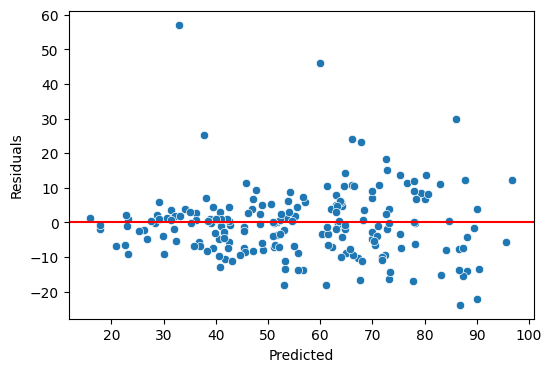

In [53]:
residuals = y_test - y_predict

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_predict,y=residuals)

plt.axhline(0,color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals") 

#### Actual vs Predicted Plot

Text(0, 0.5, 'Predicted')

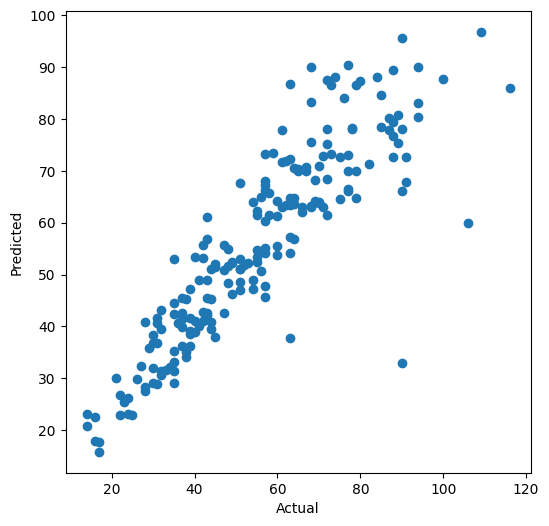

In [54]:
plt.figure(figsize=(6,6))

plt.scatter(y_test,y_predict)

plt.xlabel("Actual")

plt.ylabel("Predicted")